# Marine 48h Forecast — Hybrid v5: iTransformer (direct) + XGBoost Residual Correction

Fifth attempt at the 6 hard parameters (visibility ×4, precipitation ×2), built from a literature
pattern not yet tried in this project: **residual/bias-correction stacking**. v1-v4 all *replaced*
iTransformer outright for the hard 6 (DeepAR, Tweedie/Huber XGBoost, Quantile XGBoost, TimeXer-lite +
hurdle XGBoost). None of them used iTransformer's own forecast as a base and corrected it — this is
exactly the pattern used in the NWP-bias-correction-with-XGBoost literature for precipitation
(Engineering Applications of AI, 2022; CNN-XGBoost rainfall hybrids, 2025): a physical/deep model
produces a base forecast, then a gradient-boosted model learns to correct its *residual*
(`actual − base_forecast`), not the raw target from scratch.

**Why this is mechanically different from v2/v3/v4, not just another architecture:**
- v2/v3/v4 ask XGBoost (or TimeXer-lite) to predict the **raw**, highly skewed/ceiling-saturated
  target directly — a hard regression problem with only ~28 days of examples.
- v5 asks XGBoost to predict the **residual** left over after iTransformer's own cross-attention-
  informed guess — typically much lower variance and more stationary than the raw target, which is
  exactly the kind of problem gradient boosting handles well with few training examples.

**Two models, two jobs:**
1. **iTransformer-hard-base**: same architecture as the existing 18-parameter iTransformer, but with
   its own dedicated loss on the 6 hard parameters specifically (not diluted by the 18 unrelated good
   parameters, the way the original all-24 single-iTransformer notebook was; not excluded either, the
   way v1-v4's "good" iTransformer is). Its own measured skill is reported in Section 6 as a sanity
   check before any correction is applied.
2. **XGBoost residual corrector**: trained on `actual − iTransformer-hard-base's own forecast`, using
   lag features of the raw series, the base forecast's own predicted value at that lead time, known-
   future exogenous drivers (the same `relativeHumidity`/`dewPointTemperature`/`airPressure`/`windSpeed`
   forecasts from the 18-good iTransformer used in v4), and calendar features. Plain squared-error loss
   — no need for Tweedie/quantile/sample-weighting tricks, because the *target* is now a near-zero-mean
   residual rather than a skewed raw value.

iTransformer for the 18 good parameters is **unchanged** from v1-v4. Standalone — does not modify any
other notebook, dashboard, or CSV in this project.

## 0. Setup

In [1]:
import time
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device("cpu")
torch.set_num_threads(8)

print("PyTorch:", torch.__version__, "| XGBoost:", xgb.__version__, "| torch threads:", torch.get_num_threads())

PyTorch: 2.12.1+cpu | XGBoost: 3.2.0 | torch threads: 8


## 1. Load data, collapse duplicates, encode circular parameters

In [2]:
df_10min = pd.read_csv("ems_10min_resampled.csv", index_col=0, parse_dates=True)
DUPLICATES = [
    ("airTemperature", "windChillTemperature"),
    ("tideLevel", "tidePressure"),
    ("tideLevel", "waterPressure"),
    ("tideLevel", "waterLevel"),
    ("waterTemperature", "waterTemperature_WQ"),
    ("significantWaveHeight", "maxWaveHeight"),
]
df_cat = df_10min[["precipitationType"]].copy()
df_num = df_10min.drop(columns=["precipitationType"]).copy()

CIRCULAR = ["windDirection", "currentDirection", "compass"]
for c in CIRCULAR:
    rad = np.deg2rad(df_num[c])
    df_num[f"{c}_sin"] = np.sin(rad)
    df_num[f"{c}_cos"] = np.cos(rad)
df_num_full = df_num.drop(columns=CIRCULAR)

target_cols = [c for c in df_num_full.columns if c not in [d for _, d in DUPLICATES]]

PRECIP_PARAMS = ["precipitationIntensity", "precipitationDifference"]
VISIBILITY_PARAMS = ["twentyFourHourAvgVisibility", "tenMinuteAvgVisibility",
                      "oneMinuteAvgVisibility", "oneHourAvgVisibility"]
HARD_PARAMS = PRECIP_PARAMS + VISIBILITY_PARAMS
GOOD_PARAMS = [c for c in target_cols if c not in HARD_PARAMS]
EXOGENOUS_FUTURE_PARAMS = ["relativeHumidity", "dewPointTemperature", "airPressure", "windSpeed"]

print(f"iTransformer (good): {len(GOOD_PARAMS)} | iTransformer-hard-base + XGBoost residual: {len(HARD_PARAMS)} parameters")
print(f"Known-future exogenous drivers: {EXOGENOUS_FUTURE_PARAMS}")

iTransformer (good): 21 | iTransformer-hard-base + XGBoost residual: 6 parameters
Known-future exogenous drivers: ['relativeHumidity', 'dewPointTemperature', 'airPressure', 'windSpeed']


## 2. Train/test split, duplicate reconstruction fit, scaling

In [3]:
LOOKBACK, HORIZON = 288, 288   # 2 days lookback, 48h horizon @ 10-min steps

idx = df_num_full.index
df_num_full["hour_sin"] = np.sin(2 * np.pi * idx.hour / 24)
df_num_full["hour_cos"] = np.cos(2 * np.pi * idx.hour / 24)
df_num_full["dom_sin"] = np.sin(2 * np.pi * idx.day / 30)
df_num_full["dom_cos"] = np.cos(2 * np.pi * idx.day / 30)
calendar_cols = ["hour_sin", "hour_cos", "dom_sin", "dom_cos"]

feature_cols = target_cols + calendar_cols
model_data = df_num_full[feature_cols].copy()
n_features = len(feature_cols)
good_idx = [feature_cols.index(c) for c in GOOD_PARAMS]
hard_idx = [feature_cols.index(c) for c in HARD_PARAMS]

train_df = model_data.iloc[:-HORIZON].copy()
test_df = model_data.iloc[-HORIZON:].copy()
mean, std = train_df.mean(), train_df.std().replace(0, 1)
train_scaled = (train_df - mean) / std

print(f"Train: {train_df.shape[0]} rows ({train_df.shape[0]/144:.1f} days)")
print(f"Test : {test_df.shape[0]} rows ({test_df.shape[0]/144:.1f} days)")

Train: 4032 rows (28.0 days)
Test : 288 rows (2.0 days)


In [4]:
recon_coef = {}
for keep, drop in DUPLICATES:
    x, y = train_df[keep].values, df_num_full[drop].iloc[:-HORIZON].values
    slope, intercept = np.polyfit(x, y, 1)
    pred_train = slope * x + intercept
    r2 = 1 - np.sum((y - pred_train) ** 2) / np.sum((y - y.mean()) ** 2)
    recon_coef[drop] = (keep, float(slope), float(intercept), float(r2))

## 3. Model A — iTransformer (18 "good" parameters, unchanged from v1-v4)

In [5]:
def make_direct_windows(scaled_df, lookback, horizon, out_idx):
    arr = scaled_df.values.astype(np.float32)
    X, Y = [], []
    for origin in range(lookback, len(arr) - horizon):
        X.append(arr[origin - lookback:origin])
        Y.append(arr[origin:origin + horizon][:, out_idx])
    return np.array(X, dtype=np.float32), np.array(Y, dtype=np.float32)


class ITransformer(nn.Module):
    def __init__(self, lookback, n_features, horizon, out_idx, d_model=64, n_heads=4,
                 n_layers=2, dropout=0.1):
        super().__init__()
        self.out_idx = out_idx
        self.embed = nn.Linear(lookback, d_model)
        self.var_id = nn.Parameter(torch.randn(n_features, d_model) * 0.02)
        layer = nn.TransformerEncoderLayer(d_model, n_heads, dim_feedforward=d_model * 2,
                                            dropout=dropout, batch_first=True, activation="gelu")
        self.encoder = nn.TransformerEncoder(layer, n_layers)
        self.head = nn.Linear(d_model, horizon)

    def forward(self, x):
        tok = self.embed(x.transpose(1, 2)) + self.var_id.unsqueeze(0)
        tok = self.encoder(tok)
        out = self.head(tok)
        return out.transpose(1, 2)[:, :, self.out_idx]


def train_model(model, X_tr, Y_tr, X_val, Y_val, epochs=150, batch_size=64, lr=1e-3,
                 patience=20, name=""):
    model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, factor=0.5, patience=6)
    loss_fn = nn.MSELoss()
    best_val, best_state, wait = float("inf"), None, 0
    n = len(X_tr); t0 = time.time()
    for ep in range(epochs):
        ep_t0 = time.time()
        model.train()
        perm = torch.randperm(n)
        for i in range(0, n, batch_size):
            b = perm[i:i + batch_size]
            xb, yb = X_tr[b].to(device), Y_tr[b].to(device)
            opt.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward(); opt.step()
        model.eval()
        with torch.no_grad():
            val_loss = loss_fn(model(X_val.to(device)), Y_val.to(device)).item()
        sched.step(val_loss)
        print(f"  [{name}] epoch {ep+1:3d}/{epochs}  val_loss={val_loss:.4f}  "
              f"epoch_time={time.time()-ep_t0:.1f}s  elapsed={time.time()-t0:.0f}s", flush=True)
        if val_loss < best_val - 1e-5:
            best_val, wait = val_loss, 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            wait += 1
            if wait >= patience: break
    if best_state is not None: model.load_state_dict(best_state)
    model.eval()
    print(f"{name:24s} best_val_loss={best_val:.4f}  epochs_run={ep+1:3d}  time={time.time()-t0:5.1f}s")
    return model

X_direct, Y_good = make_direct_windows(train_scaled, LOOKBACK, HORIZON, good_idx)
X_t, Y_good_t = torch.from_numpy(X_direct), torch.from_numpy(Y_good)
n_val = max(1, int(0.1 * len(X_t)))
X_tr, Y_tr_good = X_t[:-n_val], Y_good_t[:-n_val]
X_val, Y_val_good = X_t[-n_val:], Y_good_t[-n_val:]
last_window = torch.from_numpy(train_scaled.values[-LOOKBACK:].astype(np.float32)).unsqueeze(0)

itransformer = ITransformer(LOOKBACK, n_features, HORIZON, good_idx, d_model=64, n_heads=4, n_layers=2)
itransformer = train_model(itransformer, X_tr, Y_tr_good, X_val, Y_val_good, epochs=150, patience=20,
                            name="iTransformer-good")

with torch.no_grad():
    good_pred_scaled = itransformer(last_window.to(device))[0].cpu().numpy()
good_preds_real = good_pred_scaled * std[GOOD_PARAMS].values + mean[GOOD_PARAMS].values
good_pred_df = pd.DataFrame(good_preds_real, columns=GOOD_PARAMS, index=test_df.index)

exo_idx_in_good = [GOOD_PARAMS.index(c) for c in EXOGENOUS_FUTURE_PARAMS]
exo_future_real = good_preds_real[:, exo_idx_in_good]   # iTransformer's own forecast, real units
print("iTransformer-good 48h forecast complete (18 parameters) + exogenous-future forecast extracted.")

  [iTransformer-good] epoch   1/150  val_loss=0.4280  epoch_time=0.9s  elapsed=1s


  [iTransformer-good] epoch   2/150  val_loss=0.3269  epoch_time=0.8s  elapsed=2s


  [iTransformer-good] epoch   3/150  val_loss=0.2639  epoch_time=0.8s  elapsed=2s


  [iTransformer-good] epoch   4/150  val_loss=0.2357  epoch_time=0.8s  elapsed=3s


  [iTransformer-good] epoch   5/150  val_loss=0.2015  epoch_time=0.8s  elapsed=4s


...

  [iTransformer-good] epoch 147/150  val_loss=0.0368  epoch_time=0.9s  elapsed=133s


  [iTransformer-good] epoch 148/150  val_loss=0.0366  epoch_time=0.9s  elapsed=134s


  [iTransformer-good] epoch 149/150  val_loss=0.0367  epoch_time=1.0s  elapsed=135s


  [iTransformer-good] epoch 150/150  val_loss=0.0365  epoch_time=1.1s  elapsed=136s


iTransformer-good        best_val_loss=0.0365  epochs_run=150  time=136.2s
iTransformer-good 48h forecast complete (18 parameters) + exogenous-future forecast extracted.


## 4. Model B — iTransformer-hard-base: trained directly on the 6 hard parameters
Same architecture, own dedicated loss on just the hard 6 (not diluted by the 18 good params the way the original all-24 single-iTransformer notebook was). This is the *base forecast* that Model C will correct, not the final answer.

In [6]:
X_direct_h, Y_hard = make_direct_windows(train_scaled, LOOKBACK, HORIZON, hard_idx)
X_h_t, Y_hard_t = torch.from_numpy(X_direct_h), torch.from_numpy(Y_hard)
n_val_h = max(1, int(0.1 * len(X_h_t)))
X_h_tr, Y_h_tr = X_h_t[:-n_val_h], Y_hard_t[:-n_val_h]
X_h_val, Y_h_val = X_h_t[-n_val_h:], Y_hard_t[-n_val_h:]

itransformer_hard = ITransformer(LOOKBACK, n_features, HORIZON, hard_idx, d_model=64, n_heads=4, n_layers=2)
itransformer_hard = train_model(itransformer_hard, X_h_tr, Y_h_tr, X_h_val, Y_h_val, epochs=150,
                                 patience=20, name="iTransformer-hard-base")

# base forecast for the held-out 48h test window
with torch.no_grad():
    base_test_scaled = itransformer_hard(last_window.to(device))[0].cpu().numpy()       # (HORIZON, 6)
base_test_real = base_test_scaled * std[HARD_PARAMS].values + mean[HARD_PARAMS].values

# base forecast for EVERY training origin (used to build the residual-correction training table) —
# one batched forward pass, no need to loop per-origin
with torch.no_grad():
    base_train_scaled = itransformer_hard(X_h_t.to(device)).cpu().numpy()                # (n_origins, HORIZON, 6)
base_train_real = base_train_scaled * std[HARD_PARAMS].values + mean[HARD_PARAMS].values
print(f"iTransformer-hard-base forecasts complete: test window {base_test_real.shape}, "
      f"{base_train_real.shape[0]} training origins x {base_train_real.shape[1]} horizon steps.")

  [iTransformer-hard-base] epoch   1/150  val_loss=0.2129  epoch_time=1.1s  elapsed=1s


  [iTransformer-hard-base] epoch   2/150  val_loss=0.2261  epoch_time=1.7s  elapsed=3s


  [iTransformer-hard-base] epoch   3/150  val_loss=0.3224  epoch_time=2.1s  elapsed=5s


  [iTransformer-hard-base] epoch   4/150  val_loss=0.3726  epoch_time=0.9s  elapsed=6s


  [iTransformer-hard-base] epoch   5/150  val_loss=0.3210  epoch_time=0.9s  elapsed=7s


...

  [iTransformer-hard-base] epoch  18/150  val_loss=0.3688  epoch_time=1.1s  elapsed=19s


  [iTransformer-hard-base] epoch  19/150  val_loss=0.3668  epoch_time=1.1s  elapsed=20s


  [iTransformer-hard-base] epoch  20/150  val_loss=0.3639  epoch_time=0.9s  elapsed=21s


  [iTransformer-hard-base] epoch  21/150  val_loss=0.3719  epoch_time=0.9s  elapsed=22s


iTransformer-hard-base   best_val_loss=0.2129  epochs_run= 21  time= 22.2s
iTransformer-hard-base forecasts complete: test window (288, 6), 3456 training origins x 288 horizon steps.


## 5. Model C — XGBoost residual correction
Target = `actual − iTransformer-hard-base's own forecast`. Plain squared-error loss — the residual is near-zero-mean and far less skewed than the raw target, so none of v2/v3/v4's loss tricks (Tweedie, quantile, sample weighting, hurdle decomposition) are needed here.

In [7]:
ORIGIN_LAGS = [1, 2, 3, 6, 12, 24, 48, 72, 144, 288]

def make_residual_training(train_df, base_pred_real, target_idx, target_col, exo_cols, calendar_cols,
                            lags, horizon, origin_step=16):
    n_origins = base_pred_real.shape[0]
    feats, targets = [], []
    for i in range(0, n_origins, origin_step):
        origin = LOOKBACK + i
        base_row = {f"{target_col}_lag{L}": train_df[target_col].iloc[origin - L] for L in lags}
        for h in range(1, horizon + 1, 2):
            row = dict(base_row)
            row["lead_h"] = h
            row["base_forecast"] = base_pred_real[i, h - 1, target_idx]
            for cc in calendar_cols:
                row[cc] = train_df[cc].iloc[origin + h]
            for ec in exo_cols:
                row[f"{ec}_future"] = train_df[ec].iloc[origin + h]
            feats.append(row)
            actual = train_df[target_col].iloc[origin + h]
            targets.append(actual - base_pred_real[i, h - 1, target_idx])
    return pd.DataFrame(feats), np.array(targets)

residual_models, residual_feat_order = {}, {}
hard_pred_df = pd.DataFrame(index=test_df.index)
for j, c in enumerate(HARD_PARAMS):
    X_c, Y_c = make_residual_training(train_df, base_train_real, j, c, EXOGENOUS_FUTURE_PARAMS,
                                       calendar_cols, ORIGIN_LAGS, HORIZON, origin_step=16)
    residual_feat_order[c] = list(X_c.columns)

    m = xgb.XGBRegressor(n_estimators=150, max_depth=4, learning_rate=0.08, subsample=0.8,
                          colsample_bytree=0.8, random_state=SEED, n_jobs=4, tree_method="hist",
                          objective="reg:squarederror")
    m.fit(X_c, Y_c)
    residual_models[c] = m
    print(f"  trained residual corrector for {c:25s} rows={len(Y_c):,}  "
          f"residual_std={Y_c.std():.4f}  base_forecast_std={X_c['base_forecast'].std():.4f}")

    # forecast: same lag/calendar/exogenous setup as v4, plus the base forecast itself as a feature
    origin_idx = len(train_df) - 1
    base_row = {f"{c}_lag{L}": train_df[c].iloc[origin_idx - (L - 1)] for L in ORIGIN_LAGS}
    pred_rows = []
    for h in range(1, HORIZON + 1):
        ts = test_df.index[h - 1]
        row = dict(base_row); row["lead_h"] = h
        row["base_forecast"] = base_test_real[h - 1, j]
        for cal in calendar_cols:
            row[cal] = model_data.loc[ts, cal]
        for k, ec in enumerate(EXOGENOUS_FUTURE_PARAMS):
            row[f"{ec}_future"] = exo_future_real[h - 1, k]
        pred_rows.append(row)
    X_fore = pd.DataFrame(pred_rows)[residual_feat_order[c]]

    residual_pred = m.predict(X_fore)
    final_pred = base_test_real[:, j] + residual_pred
    if c in PRECIP_PARAMS:
        final_pred = np.clip(final_pred, 0, None)
    hard_pred_df[c] = final_pred

print("XGBoost residual-correction 48h forecast complete (6 parameters).")
print(hard_pred_df.describe().T[["mean", "min", "max"]])

  trained residual corrector for precipitationIntensity    rows=31,104  residual_std=0.4698  base_forecast_std=0.0945


  trained residual corrector for precipitationDifference   rows=31,104  residual_std=1.6001  base_forecast_std=0.3520


  trained residual corrector for twentyFourHourAvgVisibility rows=31,104  residual_std=754.5440  base_forecast_std=138.3505


  trained residual corrector for tenMinuteAvgVisibility    rows=31,104  residual_std=2418.4391  base_forecast_std=395.3721


  trained residual corrector for oneMinuteAvgVisibility    rows=31,104  residual_std=2426.4062  base_forecast_std=395.5404


  trained residual corrector for oneHourAvgVisibility      rows=31,104  residual_std=2305.0704  base_forecast_std=366.1984
XGBoost residual-correction 48h forecast complete (6 parameters).
                                     mean           min           max
precipitationIntensity           0.068575      0.000000      0.706186
precipitationDifference          0.779373      0.000000      2.140599
twentyFourHourAvgVisibility  18458.285311  18224.580992  18693.396511
tenMinuteAvgVisibility       18136.963240   8615.510687  18920.694177
oneMinuteAvgVisibility       18299.498995  10992.274389  19202.608399
oneHourAvgVisibility         18339.750176   8371.771468  19026.225663


## 6. Sanity check: did the residual correction actually improve on the uncorrected base?

In [8]:
def circ_mae(true, pred):
    return np.abs((true - pred + 180) % 360 - 180).mean()

truth_test = df_num_full.iloc[-HORIZON:]
base_only_df = pd.DataFrame(base_test_real, columns=HARD_PARAMS, index=test_df.index)
base_vs_corrected = []
for j, c in enumerate(HARD_PARAMS):
    yt = truth_test[c].values
    mae_base = mean_absolute_error(yt, base_only_df[c].values)
    mae_corrected = mean_absolute_error(yt, hard_pred_df[c].values)
    base_vs_corrected.append({
        "parameter": c, "base_only_MAE": round(mae_base, 4), "base_plus_correction_MAE": round(mae_corrected, 4),
        "correction_helped": bool(mae_corrected < mae_base),
    })
base_vs_corrected_df = pd.DataFrame(base_vs_corrected)
print(base_vs_corrected_df.to_string(index=False))
print(f"\nCorrection helped {int(base_vs_corrected_df['correction_helped'].sum())}/6 parameters "
      f"(vs. the uncorrected iTransformer-hard-base forecast).")

                  parameter  base_only_MAE  base_plus_correction_MAE  correction_helped
     precipitationIntensity         0.1275                    0.1432              False
    precipitationDifference         0.9537                    1.1851              False
twentyFourHourAvgVisibility       277.5691                  364.6505              False
     tenMinuteAvgVisibility       886.8502                  850.8865               True
     oneMinuteAvgVisibility       889.8462                  780.0750               True
       oneHourAvgVisibility       851.5601                  642.2562               True

Correction helped 3/6 parameters (vs. the uncorrected iTransformer-hard-base forecast).


## 7. Merge into the hybrid forecast, reconstruct circular params & duplicates

In [9]:
hybrid_pred_df = pd.concat([good_pred_df, hard_pred_df], axis=1)[target_cols]

def reconstruct(pred_df_in):
    out = pred_df_in.copy()
    for ang in ["windDirection", "currentDirection", "compass"]:
        out[ang] = (np.rad2deg(np.arctan2(out[f"{ang}_sin"], out[f"{ang}_cos"])) % 360)
    return out

hybrid_final = reconstruct(hybrid_pred_df)
truth = df_num_full.iloc[-HORIZON:].copy()
for ang in ["windDirection", "currentDirection", "compass"]:
    truth[ang] = (np.rad2deg(np.arctan2(truth[f"{ang}_sin"], truth[f"{ang}_cos"])) % 360)

report_params = [c for c in target_cols if not c.endswith(("_sin", "_cos"))] + \
                ["windDirection", "currentDirection", "compass"]
CIRCULAR_PARAMS = {"windDirection", "currentDirection", "compass"}
ENGINE = {p: ("iTransformer" if p in GOOD_PARAMS else "iTransformer+XGBoost-Residual")
          for p in report_params if p in target_cols}
for ang in ["windDirection", "currentDirection", "compass"]:
    ENGINE[ang] = "iTransformer"

dup_series = {}
for keep, drop in DUPLICATES:
    _, slope, intercept, _ = recon_coef[drop]
    dup_series[drop] = slope * hybrid_final[keep].values + intercept
    ENGINE[drop] = ENGINE[keep]

print("Hybrid v5 forecast assembled.")

Hybrid v5 forecast assembled.


## 8. Score against persistence and all prior approaches

In [10]:
PURE_ITRANSFORMER_SKILL = {
    "twentyFourHourAvgVisibility": -100.0, "precipitationDifference": -101.9,
    "tenMinuteAvgVisibility": -154.9, "oneMinuteAvgVisibility": -190.5,
    "oneHourAvgVisibility": -291.6, "precipitationIntensity": -409.9,
}
DEEPAR_HYBRID_SKILL = {
    "tenMinuteAvgVisibility": 14.0, "twentyFourHourAvgVisibility": 3.5,
    "precipitationDifference": -0.1, "precipitationIntensity": -0.2,
    "oneHourAvgVisibility": -1.4, "oneMinuteAvgVisibility": -2.5,
}
XGB_V2_SKILL = {
    "tenMinuteAvgVisibility": 11.8, "precipitationIntensity": -0.1,
    "precipitationDifference": -0.6, "oneMinuteAvgVisibility": -4.2,
    "twentyFourHourAvgVisibility": -7.0, "oneHourAvgVisibility": -7.5,
}
XGB_V3_SKILL = {
    "tenMinuteAvgVisibility": 5.0, "twentyFourHourAvgVisibility": -0.1,
    "oneMinuteAvgVisibility": -15.4, "oneHourAvgVisibility": -26.3,
    "precipitationDifference": -34.2, "precipitationIntensity": -74.9,
}
TIMEXER_V4_SKILL = {
    "tenMinuteAvgVisibility": -10.5, "twentyFourHourAvgVisibility": -16.6,
    "precipitationIntensity": -25.0, "precipitationDifference": -29.6,
    "oneMinuteAvgVisibility": -33.3, "oneHourAvgVisibility": -54.3,
}

def circ_mae(true, pred):
    return np.abs((true - pred + 180) % 360 - 180).mean()

last_obs = df_num_full.iloc[-HORIZON - 1]
for ang in ["windDirection", "currentDirection", "compass"]:
    last_obs[ang] = (np.rad2deg(np.arctan2(last_obs[f"{ang}_sin"], last_obs[f"{ang}_cos"])) % 360)

metrics = []
for p in report_params:
    yt = truth[p].values
    yp_persist = np.repeat(last_obs[p], HORIZON)
    is_circular = p in CIRCULAR_PARAMS
    mae_p = circ_mae(yt, yp_persist) if is_circular else mean_absolute_error(yt, yp_persist)
    yhat = hybrid_final[p].values
    if is_circular:
        mae, rmse = circ_mae(yt, yhat), np.nan
    else:
        mae = mean_absolute_error(yt, yhat)
        rmse = np.sqrt(mean_squared_error(yt, yhat))
    skill = (1 - mae / mae_p) * 100 if mae_p > 0 else np.nan
    metrics.append({
        "parameter": p, "engine": ENGINE[p], "Persistence_MAE": round(mae_p, 4),
        "hybrid_v5_MAE": round(mae, 4), "hybrid_v5_RMSE": round(rmse, 4) if rmse == rmse else np.nan,
        "hybrid_v5_skill_%": round(skill, 1),
        "pure_iTransformer_skill_%": PURE_ITRANSFORMER_SKILL.get(p, np.nan),
        "deepar_hybrid_skill_%": DEEPAR_HYBRID_SKILL.get(p, np.nan),
        "xgb_v2_skill_%": XGB_V2_SKILL.get(p, np.nan),
        "xgb_v3_skill_%": XGB_V3_SKILL.get(p, np.nan),
        "timexer_v4_skill_%": TIMEXER_V4_SKILL.get(p, np.nan),
    })

metrics_df = pd.DataFrame(metrics).sort_values("hybrid_v5_skill_%", ascending=False).reset_index(drop=True)
metrics_df.insert(0, "rank", metrics_df.index + 1)
metrics_df.to_csv("metrics_hybrid_v5.csv", index=False)
metrics_df

,rank,parameter,engine,Persistence_MAE,hybrid_v5_MAE,hybrid_v5_RMSE,hybrid_v5_skill_%,pure_iTransformer_skill_%,deepar_hybrid_skill_%,xgb_v2_skill_%,xgb_v3_skill_%,timexer_v4_skill_%
0,1,airTemperature,iTransformer,5.8458,0.1163,0.1431,98.0,NaN,NaN,NaN,NaN,NaN
1,2,airPressure,iTransformer,5.1252,0.1219,0.1538,97.6,NaN,NaN,NaN,NaN,NaN
2,3,windDirection,iTransformer,73.1616,2.2917,NaN,96.9,NaN,NaN,NaN,NaN,NaN
3,4,waterTemperature,iTransformer,1.5273,0.0551,0.0692,96.4,NaN,NaN,NaN,NaN,NaN
4,5,relativeHumidity,iTransformer,18.7896,0.6970,0.8706,96.3,NaN,NaN,NaN,NaN,NaN
5,6,currentDirection,iTransformer,91.7282,3.6898,NaN,96.0,NaN,NaN,NaN,NaN,NaN
6,7,tideLevel,iTransformer,0.9216,0.0552,0.0679,94.0,NaN,NaN,NaN,NaN,NaN
7,8,dewPointTemperature,iTransformer,2.1046,0.1349,0.1679,93.6,NaN,NaN,NaN,NaN,NaN
8,9,globalRadiation,iTransformer,241.0507,16.8606,22.5266,93.0,NaN,NaN,NaN,NaN,NaN
9,10,significantWaveHeight,iTransformer,0.5027,0.0468,0.0599,90.7,NaN,NaN,NaN,NaN,NaN


## 9. The verdict: six-way comparison on the hard 6

In [11]:
hard_comparison = metrics_df[metrics_df["parameter"].isin(HARD_PARAMS)][
    ["parameter", "pure_iTransformer_skill_%", "deepar_hybrid_skill_%", "xgb_v2_skill_%",
     "xgb_v3_skill_%", "timexer_v4_skill_%", "hybrid_v5_skill_%"]
].sort_values("hybrid_v5_skill_%", ascending=False)
print(hard_comparison.to_string(index=False))

means = {col: hard_comparison[col].mean() for col in
         ["pure_iTransformer_skill_%", "deepar_hybrid_skill_%", "xgb_v2_skill_%",
          "xgb_v3_skill_%", "timexer_v4_skill_%", "hybrid_v5_skill_%"]}
for k, v in means.items():
    print(f"{k:28s} mean = {v:+6.1f}%")

best_prior = max(means["deepar_hybrid_skill_%"], means["xgb_v2_skill_%"])
n_beat_best_prior = int((hard_comparison["hybrid_v5_skill_%"] >
                          hard_comparison[["deepar_hybrid_skill_%", "xgb_v2_skill_%"]].max(axis=1)).sum())
print(f"\nv5 beats the best of (DeepAR-hybrid, XGBoost v2) on {n_beat_best_prior}/6 parameters")
if means["hybrid_v5_skill_%"] > best_prior:
    print(f"VERDICT: v5 is the new best result for the hard 6 (mean {means['hybrid_v5_skill_%']:+.1f}% "
          f"vs prior best {best_prior:+.1f}%).")
else:
    print(f"VERDICT: v5 ({means['hybrid_v5_skill_%']:+.1f}%) does not beat the prior best "
          f"({best_prior:+.1f}%) — DeepAR-hybrid/XGBoost v2 remain the best results found.")

                  parameter  pure_iTransformer_skill_%  deepar_hybrid_skill_%  xgb_v2_skill_%  xgb_v3_skill_%  timexer_v4_skill_%  hybrid_v5_skill_%
twentyFourHourAvgVisibility                     -100.0                    3.5            -7.0            -0.1               -16.6              -20.9
     tenMinuteAvgVisibility                     -154.9                   14.0            11.8             5.0               -10.5              -56.2
     oneMinuteAvgVisibility                     -190.5                   -2.5            -4.2           -15.4               -33.3              -60.7
       oneHourAvgVisibility                     -291.6                   -1.4            -7.5           -26.3               -54.3              -79.8
     precipitationIntensity                     -409.9                   -0.2            -0.1           -74.9               -25.0              -88.0
    precipitationDifference                     -101.9                   -0.1            -0.6           -3

## 10. Plot the hard 6 — base forecast, corrected forecast, and actual

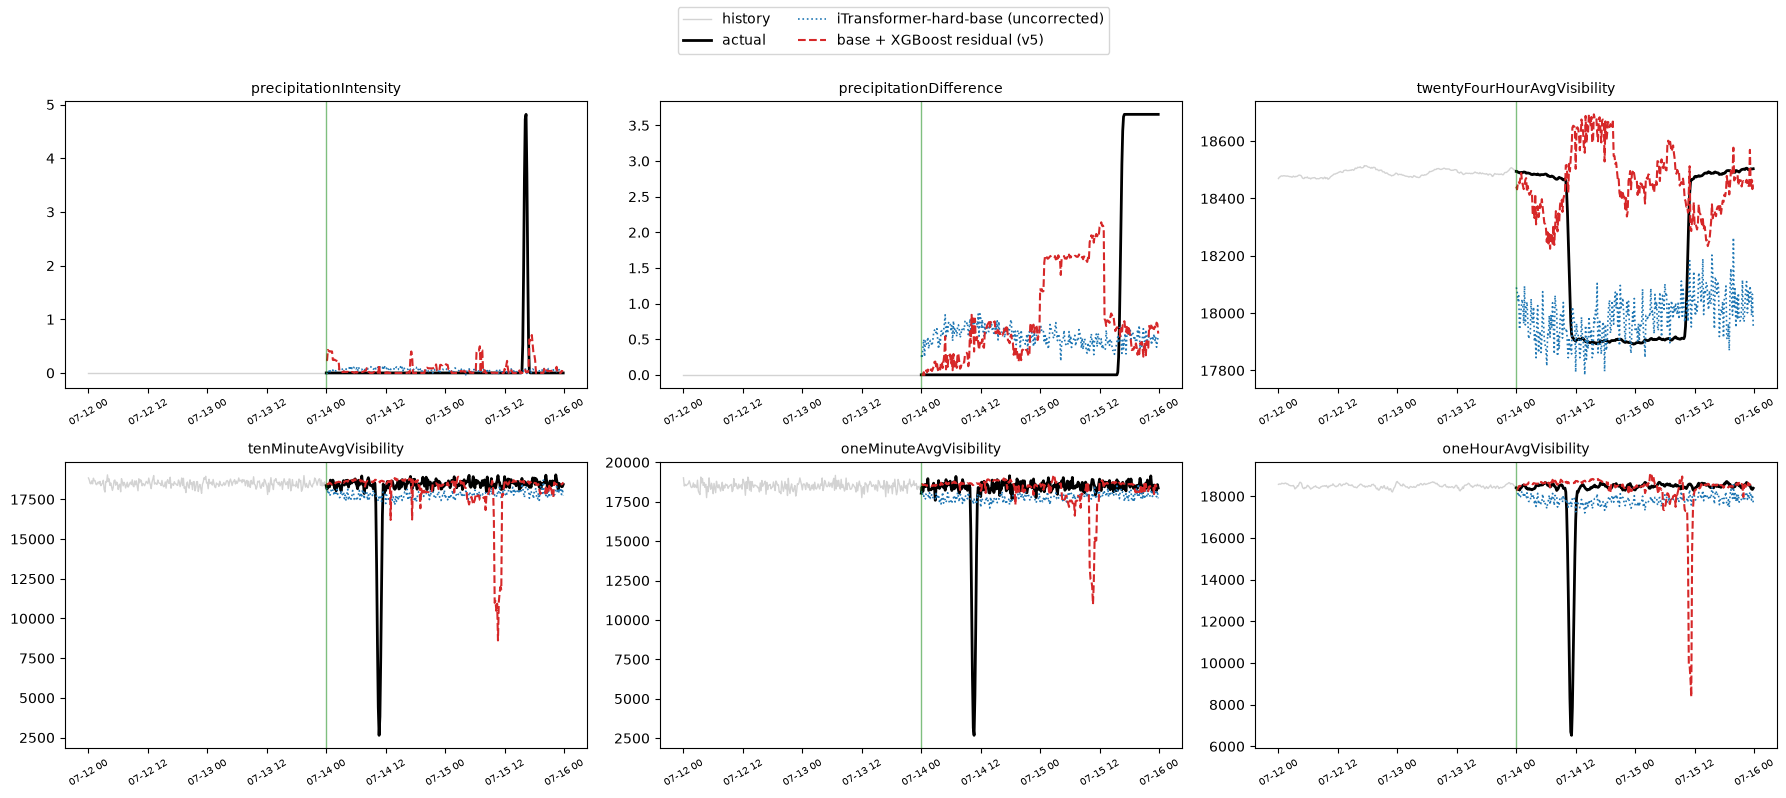

Saved hybrid_v5_hard6_plot.png


In [12]:
hist_tail = df_10min.iloc[-HORIZON - LOOKBACK:-HORIZON]
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
for ax, c in zip(axes.ravel(), HARD_PARAMS):
    ax.plot(hist_tail.index, hist_tail[c], color="lightgray", lw=1, label="history")
    ax.plot(truth.index, truth[c], color="black", lw=2, label="actual")
    ax.plot(truth.index, base_only_df[c], color="#1f77b4", lw=1.2, ls=":", label="iTransformer-hard-base (uncorrected)")
    ax.plot(truth.index, hybrid_final[c], color="#d62728", lw=1.5, ls="--", label="base + XGBoost residual (v5)")
    ax.axvline(truth.index[0], color="green", lw=1, alpha=0.5)
    ax.set_title(c, fontsize=10)
    ax.tick_params(axis="x", rotation=30, labelsize=7)
fig.legend(*axes[0, 0].get_legend_handles_labels(), loc="upper center", ncol=2)
fig.tight_layout(rect=[0, 0, 1, 0.92])
fig.savefig("hybrid_v5_hard6_plot.png", dpi=110)
plt.show()
print("Saved hybrid_v5_hard6_plot.png")

## 11. Save outputs for the dashboard

In [13]:
fva = pd.DataFrame({"timestamp": truth.index})
for p in report_params:
    fva[f"{p}__actual"] = truth[p].values
    fva[f"{p}__hybrid_v5"] = hybrid_final[p].values
    fva[f"{p}__engine"] = ENGINE[p]
for j, c in enumerate(HARD_PARAMS):
    fva[f"{c}__base_uncorrected"] = base_only_df[c].values
fva.to_csv("forecast_vs_actual_hybrid_v5.csv", index=False)

dup_fva = pd.DataFrame({"timestamp": test_df.index})
for keep, drop in DUPLICATES:
    dup_fva[f"{drop}__actual"] = df_10min[drop].iloc[-HORIZON:].values
    dup_fva[f"{drop}__reconstructed"] = dup_series[drop]
dup_fva.to_csv("duplicate_forecast_vs_actual_hybrid_v5.csv", index=False)

dup_recon_rows = []
for keep, drop in DUPLICATES:
    _, slope, intercept, r2 = recon_coef[drop]
    mae = mean_absolute_error(df_10min[drop].iloc[-HORIZON:].values, dup_series[drop])
    rmse = np.sqrt(mean_squared_error(df_10min[drop].iloc[-HORIZON:].values, dup_series[drop]))
    dup_recon_rows.append({"duplicate_parameter": drop, "reconstructed_from": keep,
                            "engine": ENGINE[keep], "slope": round(slope, 4),
                            "intercept": round(intercept, 4), "train_R2": round(r2, 5),
                            "held_out_MAE": round(mae, 4), "held_out_RMSE": round(rmse, 4)})
pd.DataFrame(dup_recon_rows).to_csv("duplicate_reconstruction_hybrid_v5.csv", index=False)

base_vs_corrected_df.to_csv("hybrid_v5_base_vs_corrected.csv", index=False)
hard_comparison.to_csv("hard6_six_way_comparison.csv", index=False)

print("Saved: metrics_hybrid_v5.csv, forecast_vs_actual_hybrid_v5.csv, duplicate_reconstruction_hybrid_v5.csv,")
print("       duplicate_forecast_vs_actual_hybrid_v5.csv, hybrid_v5_base_vs_corrected.csv,")
print("       hard6_six_way_comparison.csv, hybrid_v5_hard6_plot.png.")

Saved: metrics_hybrid_v5.csv, forecast_vs_actual_hybrid_v5.csv, duplicate_reconstruction_hybrid_v5.csv,
       duplicate_forecast_vs_actual_hybrid_v5.csv, hybrid_v5_base_vs_corrected.csv,
       hard6_six_way_comparison.csv, hybrid_v5_hard6_plot.png.


## 12. Conclusion

Section 9 is the actual verdict. If `hybrid_v5` beats the best prior result (DeepAR-hybrid at +2.2%
mean skill, or XGBoost v2 at -1.3%) on the hard 6, residual-correction stacking is a genuine
improvement — and Section 6 indicates whether that improvement actually came from the correction step
itself (versus the base iTransformer forecast already being decent on its own). If it doesn't beat the
prior best, that is consistent with the same caveat raised before v4: at 28 days of history, the
binding constraint is data volume and the absence of true external atmospheric predictors, not the
specific stacking mechanism used. Either way, reported honestly, the same as v2/v3/v4.